# Breast Cancer Classification using Neural Network

This project uses a simple neural network to classify breast cancer tumors as benign or malignant based on medical diagnostic features.

## Objective

The objective is to build a binary classification model using neural networks to predict whether a tumor is benign or malignant.

Importing the dependencies

In [30]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

In [31]:
breast_cancer_dataset = pd.read_csv("data/breast_cancer.csv")

In [32]:
breast_cancer_dataset.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [33]:
breast_cancer_dataset.shape

(569, 33)

In [34]:
breast_cancer_dataset.isnull().sum()

,0
id,0
diagnosis,0
radius_mean,0
texture_mean,0
perimeter_mean,0
area_mean,0
smoothness_mean,0
compactness_mean,0
concavity_mean,0
concave points_mean,0


In [35]:
breast_cancer_dataset["diagnosis"].value_counts()

,count
diagnosis,
B,357
M,212


In [36]:
breast_cancer_dataset.groupby("diagnosis").mean()

,id,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
diagnosis,,,,,,,,,,,,,,,,,,,,,
B,2.654382e+07,12.146524,17.914762,78.075406,462.790196,0.092478,0.080085,0.046058,0.025717,0.174186,...,23.515070,87.005938,558.899440,0.124959,0.182673,0.166238,0.074444,0.270246,0.079442,NaN
M,3.681805e+07,17.462830,21.604906,115.365377,978.376415,0.102898,0.145188,0.160775,0.087990,0.192909,...,29.318208,141.370330,1422.286321,0.144845,0.374824,0.450606,0.182237,0.323468,0.091530,NaN


0 --> Malignant

1 --> Benign

In [37]:
breast_cancer_dataset.replace({"diagnosis":{"B":1,"M":0}},inplace=True)

/tmp/ipykernel_24985/3174474037.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  breast_cancer_dataset.replace({"diagnosis":{"B":1,"M":0}},inplace=True)


In [38]:
breast_cancer_dataset.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,0,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,0,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,0,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,0,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [39]:
breast_cancer_dataset["diagnosis"].value_counts()

,count
diagnosis,
1,357
0,212


In [40]:
X = breast_cancer_dataset.drop(columns=["diagnosis","id","Unnamed: 32"],axis=1)
Y = breast_cancer_dataset["diagnosis"]

In [41]:
print(X.shape)
print(Y.shape)

(569, 30)
(569,)


In [42]:
X.head()

,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [43]:
X_train,X_test,Y_train,Y_test = train_test_split(X,Y,test_size=0.2,random_state=2,stratify=Y)

In [44]:
print(X.shape,X_test.shape,X_train.shape)

(569, 30) (114, 30) (455, 30)


In [45]:
from sklearn.preprocessing import StandardScaler

In [46]:
scaler = StandardScaler()
X_train_std = scaler.fit_transform(X_train)
X_test_std = scaler.transform(X_test)

BUILDING THE NEURAL NETWORK

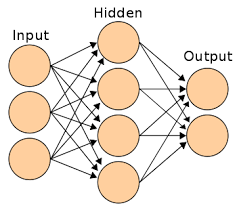

In [47]:
import tensorflow as tf
tf.random.set_seed(3)
from tensorflow import keras

In [48]:
model = keras.Sequential([
    keras.layers.Flatten(input_shape=(30,)),
    keras.layers.Dense(20,activation="relu"),
    keras.layers.Dense(2,activation="softmax")])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [49]:
model.compile(optimizer = "adam",
              loss ="sparse_categorical_crossentropy",
              metrics=["accuracy"])

In [50]:
history=model.fit(X_train_std,Y_train,validation_split=0.1,epochs=50,batch_size = 32,verbose=1)

Epoch 1/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.6235 - loss: 0.5824 - val_accuracy: 0.8478 - val_loss: 0.4326
Epoch 2/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8557 - loss: 0.4077 - val_accuracy: 0.9130 - val_loss: 0.2985
Epoch 3/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9242 - loss: 0.3027 - val_accuracy: 0.9565 - val_loss: 0.2200
Epoch 4/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9364 - loss: 0.2381 - val_accuracy: 0.9130 - val_loss: 0.1726
Epoch 5/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9438 - loss: 0.1969 - val_accuracy: 0.9348 - val_loss: 0.1438
Epoch 6/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9658 - loss: 0.1697 - val_accuracy: 0.9348 - val_loss: 0.1254
Epoch 7/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9731 - loss: 0.1509 - val_accuracy: 0.9348 - val_loss: 0.1124
Epoch 8/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9731 - loss: 0.1371 - val_accuracy: 0.9783 - val_loss

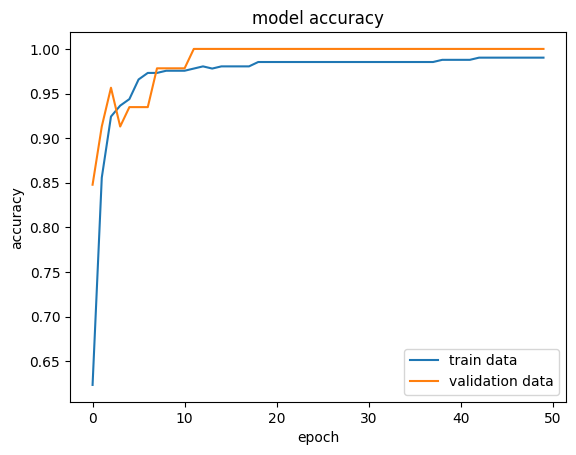

In [51]:
plt.plot(history.history["accuracy"])
plt.plot(history.history["val_accuracy"])

plt.title("model accuracy")
plt.ylabel("accuracy")
plt.xlabel("epoch")

plt.legend(["train data","validation data"],loc= "lower right")

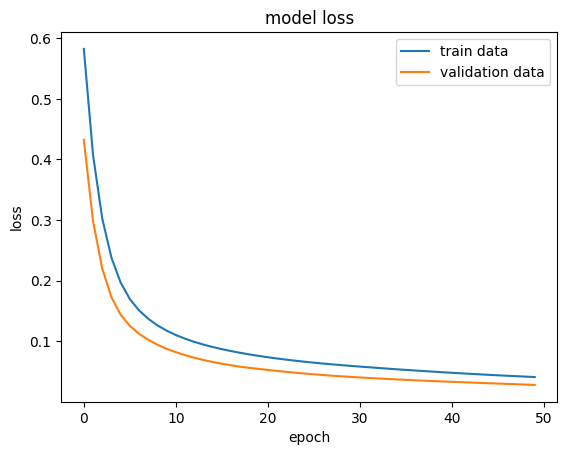

In [52]:
plt.plot(history.history["loss"])
plt.plot(history.history["val_loss"])

plt.title("model loss")
plt.ylabel("loss")
plt.xlabel("epoch")

plt.legend(["train data","validation data"],loc= "upper right")

Accuracy of the model on test data

In [53]:
Y_pred = model.predict(X_test_std)
Y_pred_labels = np.argmax(Y_pred, axis=1)

print(classification_report(Y_test, Y_pred_labels, target_names=["Malignant", "Benign"]))

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
              precision    recall  f1-score   support

   Malignant       1.00      0.98      0.99        42
      Benign       0.99      1.00      0.99        72

    accuracy                           0.99       114
   macro avg       0.99      0.99      0.99       114
weighted avg       0.99      0.99      0.99       114



In [54]:
loss, accuracy = model.evaluate(X_test_std,Y_test)
print(accuracy)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9912 - loss: 0.0484 
0.9912280440330505


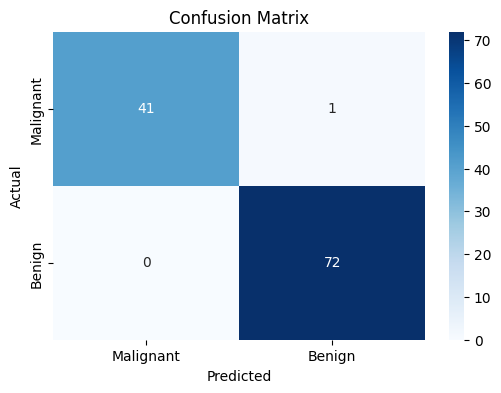

In [55]:
cm = confusion_matrix(Y_test, Y_pred_labels)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Malignant", "Benign"],
            yticklabels=["Malignant", "Benign"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [57]:
Y_pred = model.predict(X_test_std)
print(Y_pred.shape)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 
(114, 2)


In [59]:
Y_pred_labels = [np.argmax(i) for i in Y_pred]
print(Y_pred_labels)

[np.int64(0), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(0), np.int64(0), np.int64(1), np.int64(1), np.int64(0), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(0), np.int64(0), np.int64(0), np.int64(1), np.int64(1), np.int64(1), np.int64(0), np.int64(0), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(0), np.int64(0), np.int64(1), np.int64(0), np.int64(0), np.int64(1), np.int64(1), np.int64(0), np.int64(1), np.int64(1), np.int64(0), np.int64(1), np.int64(0), np.int64(1), np.int64(1), np.int64(1), np.int64(0), np.int64(1), np.int64(1), np.int64(1), np.int64(0), np.int64(0), np.int64(1), np.int64(1), np.int64(1), np.int64(0), np.int64(1), np.int64(0), np.int64(0), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(0), np.int64(1), np.int64(0)

In [60]:
sample = X_test.iloc[[0]]
sample_scaled = scaler.transform(sample)

prediction = model.predict(sample_scaled)
predicted_label = np.argmax(prediction, axis=1)[0]

if predicted_label == 1:
    print("Prediction: Benign")
else:
    print("Prediction: Malignant")

print("Actual:", "Benign" if Y_test.iloc[0] == 1 else "Malignant")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
Prediction: Malignant
Actual: Malignant


## Conclusion

In this project, a neural network was built to classify breast cancer tumors as benign or malignant.

- The dataset contained 569 samples and 30 diagnostic features.
- The target variable was encoded as 0 for malignant and 1 for benign.
- Features were standardized using StandardScaler.
- A simple neural network was trained using TensorFlow/Keras.
- The model achieved approximately 96% accuracy on the test data.
- Additional metrics such as precision, recall, F1-score, and confusion matrix were used for better evaluation.

This project is for educational purposes only and should not be used for real medical diagnosis.

In [61]:
model.save("breast_cancer_nn_model.keras")

In [62]:
import pickle

with open("scaler.pkl", "wb") as file:
    pickle.dump(scaler, file)